<a href="https://colab.research.google.com/github/jayasuneja/FWE458_Spring25/blob/main/Lecture%20Notes/FWE458_LectureNotes_L12_L13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 12 & 13: Spatial Data Analysis

Topics
* Intro to xarray
  * Data exploration
  * Indexing

* Visualizing data with xarray
  * Static plots
  * Interactive plotting

* Computing with xarray
  * Built-in functions
  * Costume functions

* Scaling computations with Dask
  * Handling out-of-memory (large) datasets
  * Parallel programming

* Accessing Cloud-Based Data Catalogs
  * Searching Earth Engine and Planetary Computer data (explore a STAC Catalog)
  * Integrating cloud data into xarray workflows

## Geospatial Data Formats for Climate and Satellite data

Key formats-- common geospatial file formats frequently used for climate and satellite data

### Net CDF (Network Common Data Form)
Purpose: storing and sharing multidimensional scientific array-based data with comprehensive metadata

Key features:
* Self-describing with rich metadata for efficient algorithm development
* Scalable for efficient access to subsets of large datasets, even remotely
* Appendable for data addition without structre redefinition
* Sharable with support for multi-user access


Common Applications:
* Gridded climate data
* Satellite images
* Earth system model outputs

CF Conventions (Climate and Forecast)
* Standardized metadata for self-description and interoperability
* Ensures variables have associated descriptions, physical units, and spatiotemporal coordinates
* Enables software tools to work effectively with minimal user intervention


### HDF5 (Heirarchical Data Format Version 5)

Purpose: storing complex heterogeneous datasets

Key Features:
* Hierarchical data organization with groups and datasets
* Self-describing with metadata within the file
* Multiple data type support (integers, floats, strings, complex numbers)
* Chunking and compression for efficient storage and access
* Large file and dataset support (terabytes to petabytes)
* Parallel processing capabilities

Common Applications
* Many satellite data (MODIS) is HDF5
* Earth system model outputs


### Zarr

Purpose: efficient parallel processing and cloud storage of large datasets

Key Features:
* Stores data in chunks across multiple files; makes reading and writing large datasets faster
* Optimized for high-performance computer (HPC), high-throughput computing (HTC), and cloud environments

Common Applications:
* Large-scale scientific datasets
* Cloud-based data analysis

### STAC (SpatioTemporal Asset Catalog)

Purpose:
* Simplify search and discovery of geospatial data across different providers and platforms
* Enable interoperability between various tools and applications working with geospatial data
* Facilitate easier cloud storage and access for large datasets

Key Features:
* Uses JSON files to describe assets, providing information like location, time, data type, metadata, and availaility
* Flexible and extensible, allowing customization for specific datat types and needs



## Basics of Xarray
1. Download Data

NOAA Physical Sciences Laboratory GHCN_CAMS product, air.mon.mean.nc, 1948/01 - 2023/12

In [1]:
# import libraries
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

import urllib.request
#Download the data
url = f"https://downloads.psl.noaa.gov/Datasets/ghcncams/air.mon.mean.nc"
savename = url.split("/")[-1]
urllib.request.urlretrieve(url, savename)

('air.mon.mean.nc', <http.client.HTTPMessage at 0x78cd024ceb90>)

Xarray: Handling NetCDF

Xarray introduces labels in the form of dimensions, coordinates and attributes on top of raw NumPy-like multidimensional arrays


Most scientific data are multidimensional arrays ; we can add labels to this matrices so we can make them easier to work with

The Pandas is a powerful Python package for this purpose but is limited to 2-D (e.g. tabular) data

You can think of Xarray as a generalized version of Pandas that can handle n-dimentional data

With Xarray, we can read, write, and process netcdf files

* DataArray: a labeled multi-dimensional array
* Dataset: a collection of DataArray objects
* Variable: a Net CDF-like variable consisting of dimensions, data, and attributes which describe a single array
* Dimension: the name of the axis of the data (e.g. in math we say 'x' dimension to describe values on x-axis) in climate data we can say 'time' dimension to describe that data has a temporal aspect
* Coordinates: an array that labels a dimension or set of dimensions of another DataArray (e.g. for 'x' axis in math we have (0,1,2,...), similarly, we can have labels for the latitude dimension

2. Open the data and explore

In [2]:
# Open the air temperature dataset
ds = xr.open_dataset(savename)
ds

<xarray.Dataset> Size: 959MB
Dimensions:  (lat: 360, lon: 720, time: 925)
Coordinates:
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * time     (time) datetime64[ns] 7kB 1948-01-01 1948-02-01 ... 2025-01-01
Data variables:
    air      (time, lat, lon) float32 959MB ...
Attributes:
    title:          NOAA/NCEP GHCN CAMS Monthly Temperature
    Conventions:    CF-1.0
    Source:         http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP/.CPC/....
    version:        3.01
    history:        created 8/2012 by CAS NOAA/ESRL PSDupdated to include maj...
    dataset_title:  Climate Prediction Center (CPC) Global Land Surface Air T...
    References:     https://www.psl.noaa.gov/data/gridded/data.ghcncams.html

In [4]:
# Extract the air temperature DataArray
ta = ds["air"]
ta

<xarray.DataArray 'air' (time: 925, lat: 360, lon: 720)> Size: 959MB
[239760000 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * time     (time) datetime64[ns] 7kB 1948-01-01 1948-02-01 ... 2025-01-01
Attributes:
    long_name:      Monthly mean of surface temperature
    units:          degK
    dataset:        NOAA/NCEP GHCN CAMS
    var_desc:       Air Temperature
    level_desc:     Surface
    statistic:      Mean
    parent_stat:    Other
    standard_name:  air_temperature
    cell_methods:   time: mean
    valid_range:    [150. 400.]
    actual_range:   [-49.21874 335.75   ]

If we already know that there is only one variable in the dataset, we can use the shortcut to load the data using xr.open_dataarray()

In [5]:
ta = xr.open_dataarray(savename)
ta

<xarray.DataArray 'air' (time: 925, lat: 360, lon: 720)> Size: 959MB
[239760000 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * time     (time) datetime64[ns] 7kB 1948-01-01 1948-02-01 ... 2025-01-01
Attributes:
    long_name:      Monthly mean of surface temperature
    units:          degK
    dataset:        NOAA/NCEP GHCN CAMS
    var_desc:       Air Temperature
    level_desc:     Surface
    statistic:      Mean
    parent_stat:    Other
    standard_name:  air_temperature
    cell_methods:   time: mean
    valid_range:    [150. 400.]
    actual_range:   [-49.21874 335.75   ]

Extract the values of the air temperature DataArray as numpy array

In [6]:
# ta.values
data = ta.data
print(data)
print(data.shape)

[[[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 ...

 [[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan n

Get dimensions names; note it's only names

In [7]:
ta.dims

('time', 'lat', 'lon')

get the coordinates; note these are array of labels (lat/lon values, timestamps)

In [8]:
ta.coords

Coordinates:
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * time     (time) datetime64[ns] 7kB 1948-01-01 1948-02-01 ... 2025-01-01

you can extract the time, latitude, and longitude coordinates

In [9]:
ta.coords["time"]

<xarray.DataArray 'time' (time: 925)> Size: 7kB
array(['1948-01-01T00:00:00.000000000', '1948-02-01T00:00:00.000000000',
       '1948-03-01T00:00:00.000000000', ..., '2024-11-01T00:00:00.000000000',
       '2024-12-01T00:00:00.000000000', '2025-01-01T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 7kB 1948-01-01 1948-02-01 ... 2025-01-01
Attributes:
    long_name:           Time
    delta_t:             0000-01-00 00:00:00
    avg_period:          0000-01-00 00:00:00
    axis:                T
    standard_name:       time
    coordinate_defines:  start
    actual_range:        [1297320. 1972320.]

get the metadata (attribute)

In [10]:
ta.attrs

{'long_name': 'Monthly mean of surface temperature',
 'units': 'degK',
 'dataset': 'NOAA/NCEP GHCN CAMS',
 'var_desc': 'Air Temperature',
 'level_desc': 'Surface',
 'statistic': 'Mean',
 'parent_stat': 'Other',
 'standard_name': 'air_temperature',
 'cell_methods': 'time: mean',
 'valid_range': array([150., 400.], dtype=float32),
 'actual_range': array([-49.21874, 335.75   ], dtype=float32)}

many functions used in numpy can be used here as well

In [11]:
ta.shape

(925, 360, 720)

Indexing and selecting data and simple plotting

Labeling data (as xarray does) make indexing and selecting data very flexible and intuitive. We can index data based on position or labels

Index like python standard method []:

In [12]:
# For example index data at the first time step and all latitudes and longitudes.
ta[1, :, :]

<xarray.DataArray 'air' (lat: 360, lon: 720)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
    time     datetime64[ns] 8B 1948-02-01
Attributes:
    long_name:      Monthly mean of surface temperature
    units:          degK
    dataset:        NOAA/NCEP GHCN CAMS
    var_desc:       Air Temperature
    level_desc:     Surface
    statistic:      Mean
    parent_stat:    Other
    standard_name:  air_temperature
    cell_methods:   time: mean
    valid_range:    [150. 400.]
    actual_range:   [-49.21874 335.75   ]

Save NetCDF files to the disk using to_netcdf()


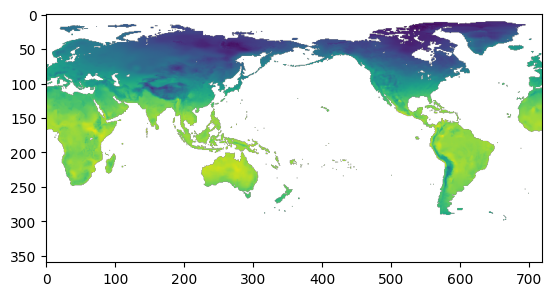

In [13]:
plt.imshow(ta[1, :, :])

In [14]:
ta.to_netcdf("ta.nc")

Quick practice: index data inclusive of the upper hemisphere for time = 100, plot it

Hint: utilize functions like range() or np.arange() for effecient indexing. For plotting extract data using .values and plot it using plt.imshow()



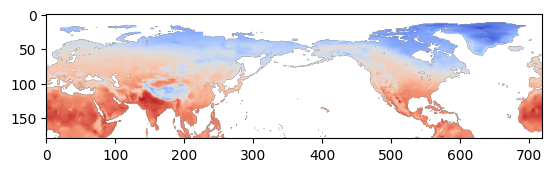

In [16]:
# first find what is the index for latitude from 0 to 90
upper_hemsphere = ta[100, 0:180, :]
plt.imshow(upper_hemsphere.values, cmap = "coolwarm")

In [17]:
# you can do same thing along lat and lon dimensions
data_isel = ta.isel(time=range(0, 6))
data_isel

<xarray.DataArray 'air' (time: 6, lat: 360, lon: 720)> Size: 6MB
array([[[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       ...,

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * time     (time) datetime64[ns] 48B 1948-01-01 1948-02-01 ... 1948-06-01
Attributes:
    long_name:      Monthly mean of surface temperature
    units:          degK
    dataset:        NOAA/NCEP GHCN CAMS
    var_desc:       Air Temperature
    level_desc:     Surface
    statistic:      Mean
    parent_stat:    Other
    standard_name:  air_temperature
    cell_methods:   time: mean
    valid_range:    [150. 400.]
    actual_range:   [-49.21874 335.75   ]

In [18]:
data_sel = ta.sel(time=["2023-08-01", "2023-09-01"])
data_sel

<xarray.DataArray 'air' (time: 2, lat: 360, lon: 720)> Size: 2MB
array([[[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * time     (time) datetime64[ns] 16B 2023-08-01 2023-09-01
Attributes:
    long_name:      Monthly mean of surface temperature
    units:          degK
    dataset:        NOAA/NCEP GHCN CAMS
    var_desc:       Air Temperature
    level_desc:     Surface
    statistic:      Mean
    parent_stat:    Other
    standard_name:  air_temperature
    cell_methods:   time: mean
    valid_range:    [150. 400.]
    actual_range:   [-49.21874 335.75   ]

In [19]:
ta.sel(time=slice("1984-01-01", "1984-12-01"))

<xarray.DataArray 'air' (time: 12, lat: 360, lon: 720)> Size: 12MB
array([[[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       ...,

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * time     (time) datetime64[ns] 96B 1984-01-01 1984-02-01 ... 1984-12-01
Attributes:
    long_name:      Monthly mean of surface temperature
    units:          degK
    dataset:        NOAA/NCEP GHCN CAMS
    var_desc:       Air Temperature
    level_desc:     Surface
    statistic:      Mean
    parent_stat:    Other
    standard_name:  air_temperature
    cell_methods:   time: mean
    valid_range:    [150. 400.]
    actual_range:   [-49.21874 335.75   ]


Nearest neighbor selection. Sometime we don' know the exact index (e.g. latitude), so we use nearest neighbor method.

Example: Here we want find closes air temperature to a specific lat and lon.

But the longitude of this file starts from 0 on its most left to 360 on its most right. Lets make it from -180 to 180.

In [20]:
# fixing longitude
# We will soon see more on basic calculations like below:
ta.coords["lon"] = (ta.coords["lon"] + 180) % 360 - 180
ta = ta.sortby(ta.lon)

Now find the nearest neighbor

<xarray.DataArray 'air' (time: 925)> Size: 4kB
array([261.12   , 261.77   , 272.3    , ..., 273.33295, 263.50113, 263.5981 ],
      dtype=float32)
Coordinates:
    lat      float32 4B 43.25
  * time     (time) datetime64[ns] 7kB 1948-01-01 1948-02-01 ... 2025-01-01
    lon      float32 4B 89.25
Attributes:
    long_name:      Monthly mean of surface temperature
    units:          degK
    dataset:        NOAA/NCEP GHCN CAMS
    var_desc:       Air Temperature
    level_desc:     Surface
    statistic:      Mean
    parent_stat:    Other
    standard_name:  air_temperature
    cell_methods:   time: mean
    valid_range:    [150. 400.]
    actual_range:   [-49.21874 335.75   ]

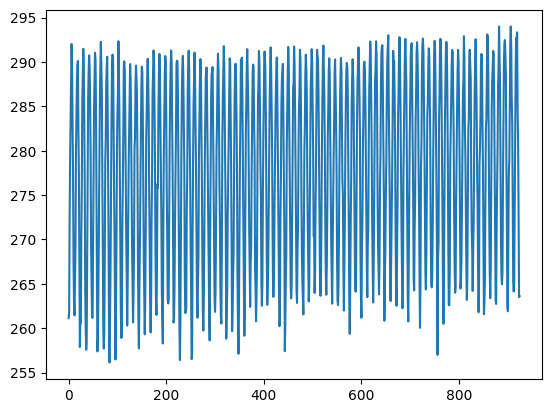

In [21]:
nearest_neighbor = ta.sel(lat=43, lon=89, method="nearest")
plt.plot(nearest_neighbor.values, "-")
nearest_neighbor

Create Mask with where()
The where() can come handy in many many situations.

For example, we can tell where in the world temperature was above/below a certain degree, create masks, find missing data and many other applications.

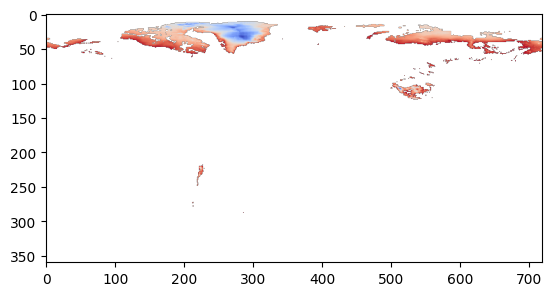

In [22]:
da = ta.sel(time="2023-05-01")
da_cold = da.where(da < 273.15)
plt.imshow(da_cold.values, cmap="coolwarm")


We can replace the masked regions and replace it with desired data.

In the code below we say find grids where temp is less than 273.15 K and replace them with temp=500 K (just because we can!), and for other region keep the original value.

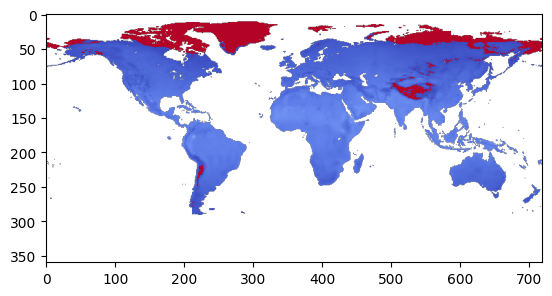

In [23]:
# Replace the below zero values with 100 (just for the sake of example)
da_hot = xr.where(da < 273.15, 500, da)
plt.imshow(da_hot.values, cmap="coolwarm")

We can replace it with other DataArrays...

In [25]:
da_tmp = xr.where(da < 273.15, ta.sel(time="1985-08-01"), da)

3. Plotting
One dimensional plot using plot()

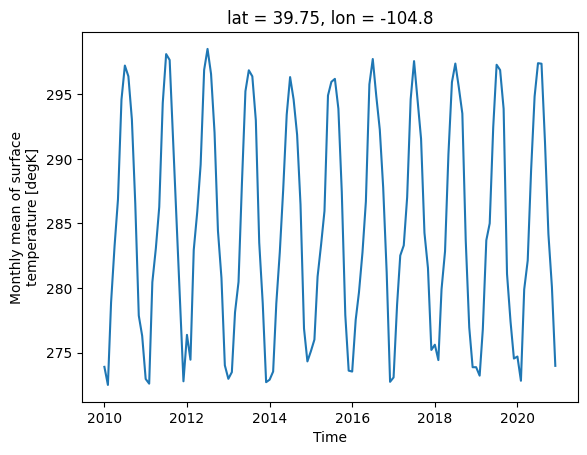

In [26]:
ta.sel(time=slice("2010-01-01", "2020-12-31")).isel(lat=100, lon=150).plot()


xarray under the hood used the matplotlib library. Any argument that goes into matplotlib can be passed to xarray

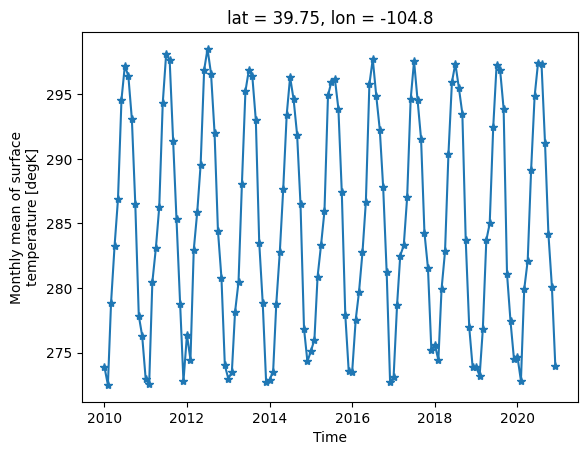

In [27]:

ta.sel(time=slice("2010-01-01", "2020-12-31")).isel(lat=100, lon=150).plot.line("-*")

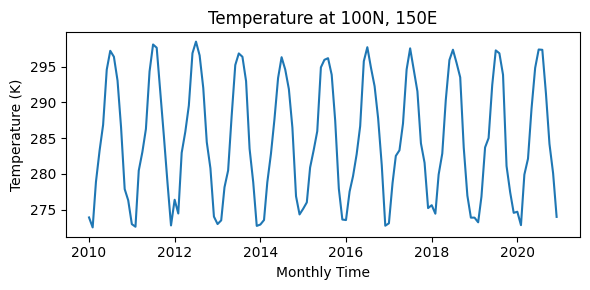

In [28]:
ta.sel(time=slice("2010-01-01", "2020-12-31")).isel(lat=100, lon=150).plot(
    aspect=2, size=3
)
plt.title("Temperature at 100N, 150E")
plt.xlabel("Monthly Time")
plt.ylabel("Temperature (K)")
plt.tight_layout()

Two dimensional plots

xarray is smart enough that in many cases it can interpret your data and choose an appropriate type.

Text(0, 0.5, 'Latitude')

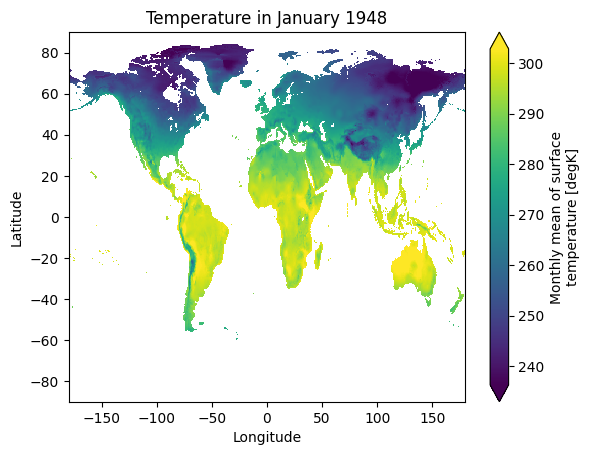

In [29]:
ta.isel(time=0).plot(robust=True)
plt.title("Temperature in January 1948")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

Faceting

Its handy when we want to plot multiple plots along a dimension (e.g. time)

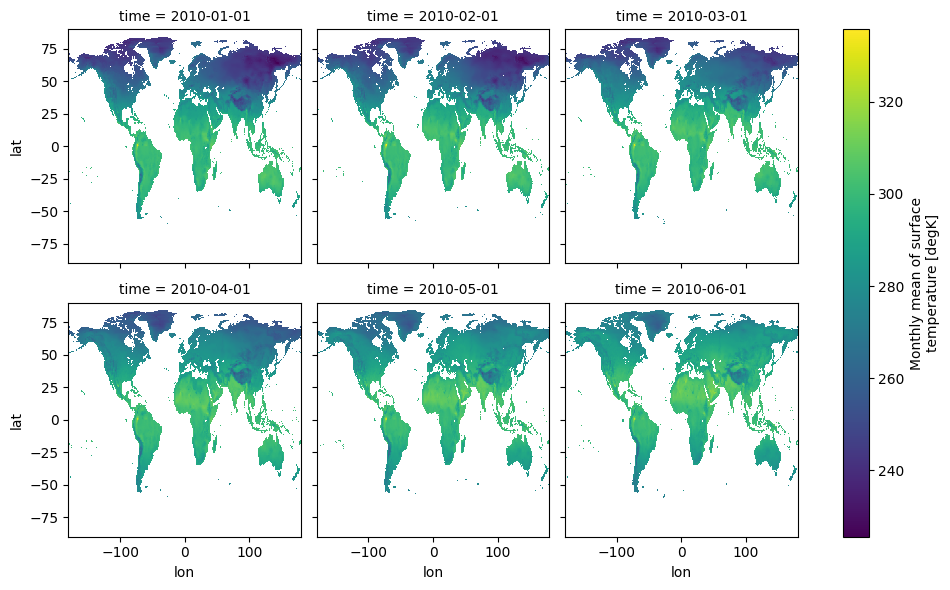

In [30]:
ta_sub = ta.sel(time=slice("2010-01-01", "2010-06-30"))
ta_sub.plot(col="time", col_wrap=3)

More advanced plots

In general the xarray basic plotting is great for data exploration (quick test).

However, it other more plotting packages were integrated with xarray to produce more complicated plots.

For example code below is how to plot it in various projections, adding coastlines etc.

In [31]:
# Install the following libraries:
!pip install cartopy geoviews hvplot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.3/547.3 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.9/161.9 kB 8.8 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


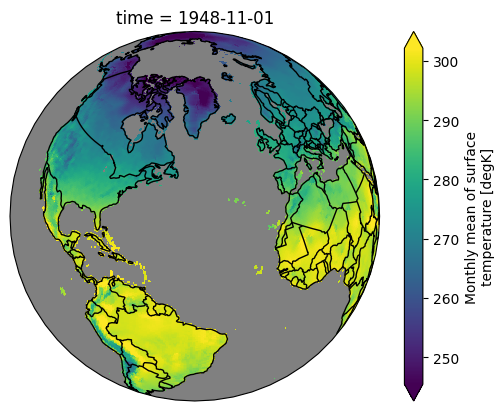

In [32]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

p = ta.isel(time=10).plot(
    subplot_kws=dict(projection=ccrs.Orthographic(-45, 35), facecolor="gray"),
    transform=ccrs.PlateCarree(),
    robust=True,
)

p.axes.coastlines()
p.axes.add_feature(cfeature.BORDERS)


Different projections

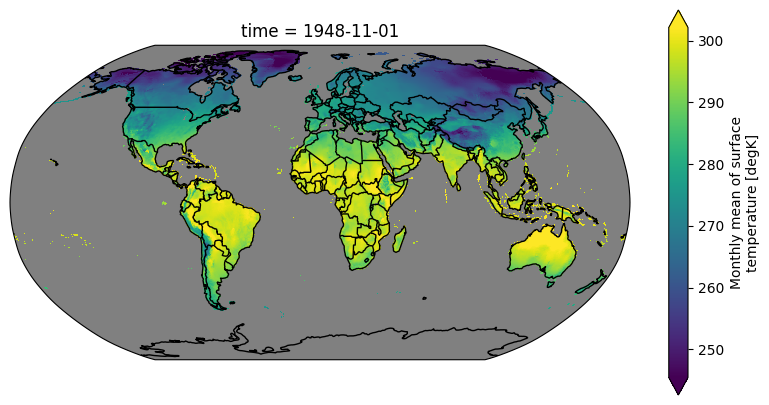

In [33]:
p = ta.isel(time=10).plot(
    subplot_kws=dict(projection=ccrs.Robinson(), facecolor="gray"),
    figsize=(10, 5),
    transform=ccrs.PlateCarree(),
    robust=True,
)

p.axes.coastlines()
p.axes.add_feature(cfeature.BORDERS)

Interactive plotting

Hover your mouse over the plot to see the temperature at different locations.

In [34]:
import hvplot.xarray

ta.isel(time=0).hvplot(
    width=800,
    height=400,
    cmap="fire",
    projection=ccrs.Mollweide(),
)

:Image   [lon,lat]   (Monthly mean of surface temperature)

Make a simple animations

In [35]:

ta.isel(time=range(12)).hvplot(
    width=800,
    height=400,
    cmap="fire",
    # projection=ccrs.Orthographic(-90, 30),
    coastline=True,
    groupby="time",
    widget_type="scrubber",
    widget_location="bottom",
)

Column
    [0] HoloViews(DynamicMap, height=400, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=800)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=11, width=550)

4. Computations

Xarray integrates seamlessly with NumPy, allowing you to apply many familiar NumPy functions directly to xarray objects (DataArrays and Datasets) while preserving their labeled structure and coordinates.

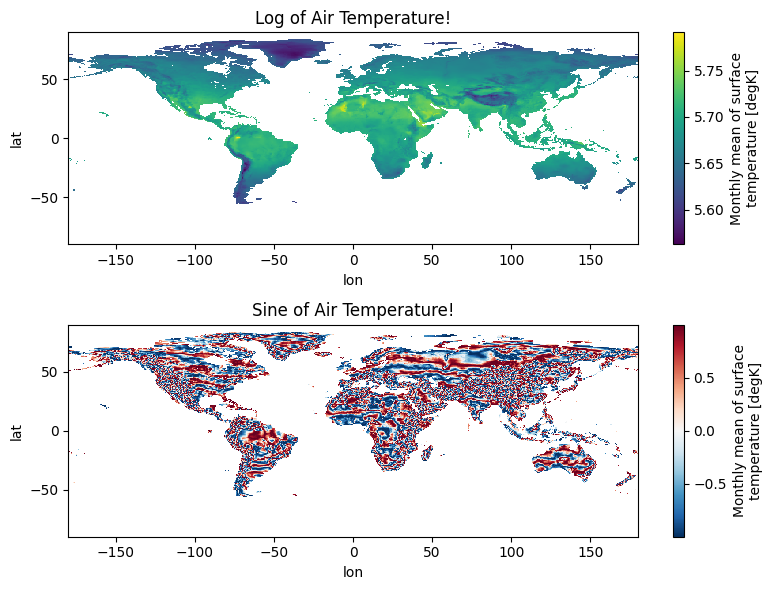

In [36]:
# For example let calculate log and sin of the air temprature, whatever they mean!
ta_sel = ta.sel(time="2023-08-01")

log_ta = np.log(ta_sel)
sin_ta = np.sin(ta_sel)

fig, axes = plt.subplots(2, 1, figsize=(8, 6))
log_ta.plot(ax=axes[0])
sin_ta.plot(ax=axes[1])

axes[0].set_title("Log of Air Temperature!")
axes[1].set_title("Sine of Air Temperature!")
plt.tight_layout()

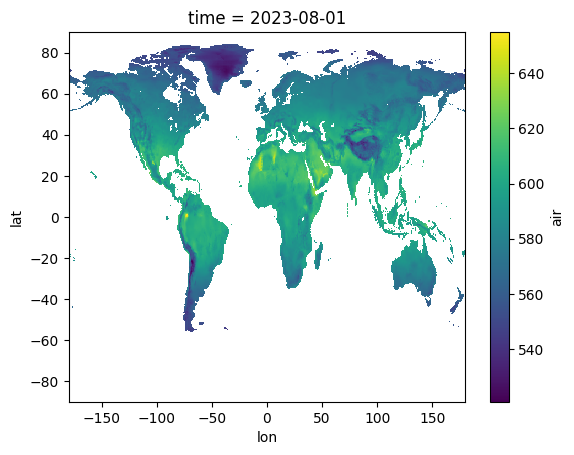

In [37]:
# Operation on two DataArrays
ta_sum = ta_sel + ta_sel
ta_sum.plot()

we can use isnull(), notnull(), fillna(), dropna() and a few more to deal with missing data

Plot grids where it is NaN and its not NaN

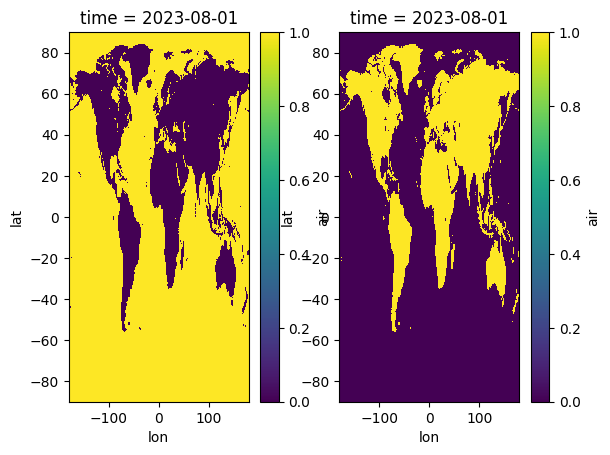

In [38]:
plt.subplot(1, 2, 1)
ta_sel.isnull().plot()
plt.subplot(1, 2, 2)
ta_sel.notnull().plot()

Fill the missing values with 0

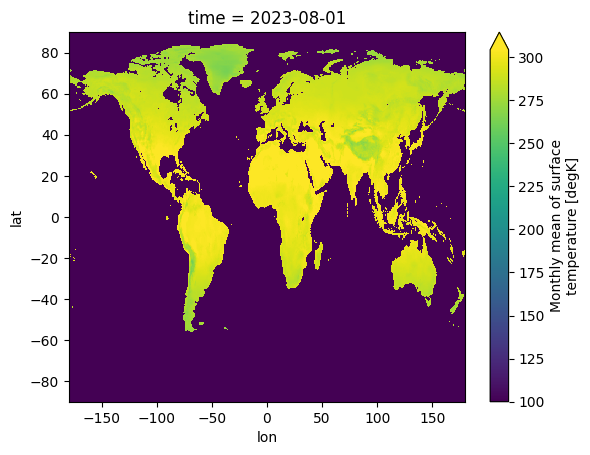

In [39]:
ta_sel.fillna(100).plot(robust=True)

Taking the mean/max/min etc.

In [40]:
ta_sel_mean = ta_sel.mean()
ta_sel_mean
# Try to sum, std, min, max, median, quantile, etc.

<xarray.DataArray 'air' ()> Size: 8B
array(291.98016357)
Coordinates:
    time     datetime64[ns] 8B 2023-08-01

Including labels (dimensions) in our calculations.

For example we can take the mean over lat and lon dimensions to get the global mean of temperature.

In [41]:
ta_mean = ta.mean(dim=["time"])
print(ta_mean)
# ta_mean.sel(time=slice("2020-01-01", "2022-12-01")).plot()

<xarray.DataArray 'air' (lat: 360, lon: 720)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8


Practice: plot the map of global temp mean from the year 1990 to 2010

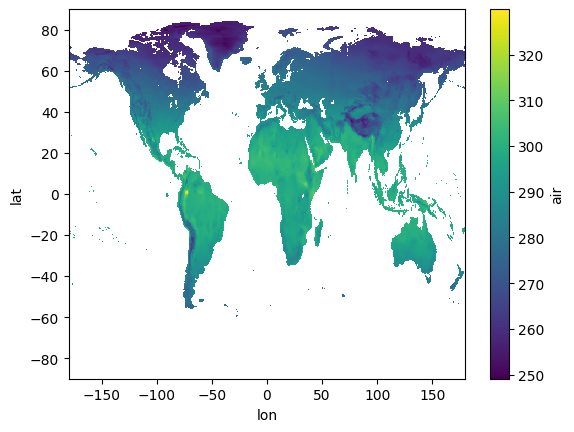

In [42]:
ta.sel(time=slice("1990-01-01", "2010-12-01")).mean(dim="time").plot()